In [1]:
import numpy as np
import pandas as pd 
import os
import spacy


for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/datasets/mdtalhask/ai-powered-resume-screening-dataset-2025/AI_Resume_Screening.csv
/kaggle/input/datasets/adityarajsrv/job-descriptions-2025-tech-and-non-tech-roles/job_dataset.json
/kaggle/input/datasets/adityarajsrv/job-descriptions-2025-tech-and-non-tech-roles/job_dataset.csv
/kaggle/input/datasets/ramzybakir/ai-generated-resume-dataset/SYRA_Generated_Resumes_dataset.csv
/kaggle/input/datasets/kawsertalukder/resume-screening-dataset4500/ml_resume_dataset_4500.csv


In [2]:
resume = pd.read_csv('../input/datasets/ramzybakir/ai-generated-resume-dataset/SYRA_Generated_Resumes_dataset.csv')
resume.head()
# resume.columns
# resume.shape
# resume['str_resume'][0]

,application_name,str_resume
0,Adebayo Oluwaseun.pdf,Adebayo Oluwaseun \nAI Ethics Specialist | a...
1,Aditi Sharma.pdf,Aditi Sharma \nData Science Manager | aditi....
2,Aditi Singh.pdf,Aditi Singh \nMachine Learning Researcher | ...
3,Aditya Sharma.pdf,Aditya Sharma \nAI Research Scientist | adit...
4,Ahmed Al-Mansoori.pdf,Ahmed Al -Mansoori \nMachine Learning Enginee...


In [3]:
'''
FEATURE EXTRACTION
'''
import re

def extract_name(text):
    first_line = text.strip().split("\n")[0]
    return first_line.strip()

def extract_job_title(text):
    lines = [l.strip() for l in text.split("\n") if l.strip()]
    if len(lines) > 1:
        title_line = lines[1]
         # Split at | and keep first part
        title = title_line.split("|")[0].strip()
        return title
    return None
    
def extract_section(text, section_name):
    pattern = rf"{section_name}\s*(.*?)\s*(?=\n[A-Z][A-Za-z ]+\n|$)"
    match = re.search(pattern, text, re.S | re.I)
    return match.group(1).strip() if match else None

def extract_skills(text):
    skills_text = extract_section(text, "Skills")
    if skills_text:
        skills = re.findall(r"•\s*(.*)", skills_text)
        return ", ".join(skills)
    return None

def extract_education(text):
    edu_text = extract_section(text, "Education")
    if edu_text:
        edu = re.findall(r"•\s*(.*)", edu_text)
        return " | ".join(edu)
    return None
    
def extract_certifications(text):
    cert_text = extract_section(text, "Certifications")
    if cert_text:
        certs = re.findall(r"•\s*(.*)", cert_text)
        return " | ".join(certs)
    return None

def extract_experience_years(text):
    match = re.search(r'(\d+)\+?\s+years? of experience', text, re.I)
    if match:
        return int(match.group(1))
    return None



In [4]:
resume['name'] = resume['str_resume'].apply(extract_name)
resume['job_role'] = resume['str_resume'].apply(extract_job_title)
resume['skills'] = resume['str_resume'].apply(extract_skills)
resume['education'] = resume['str_resume'].apply(extract_education)
resume['certifications'] = resume['str_resume'].apply(extract_certifications)
resume['experience_years'] = resume['str_resume'].apply(extract_experience_years)
resume[['name','job_role','skills','education','certifications','experience_years']].head()
# resume['certifications'][0]


,name,job_role,skills,education,certifications,experience_years
0,Adebayo Oluwaseun,AI Ethics Specialist,"AI Ethics : Fairness, Accountability, Transpar...",Master of Science in Data Ethics & AI | Univer...,Ethical AI Certification - AI Ethics Institute...,6.0
1,Aditi Sharma,Data Science Manager,,Master of Technology in Data Science | Indian ...,AWS Certified Machine Learning – Specialty |...,8.0
2,Aditi Singh,Machine Learning Researcher,,,AWS Certified Machine Learning - Specialty • ...,NaN
3,Aditya Sharma,AI Research Scientist,"Deep Learning : TensorFlow, Keras, PyTorch , ...",Doctor of Philosophy (Ph.D.) in Artificial Int...,Advanced Deep Learning Specialization - Course...,5.0
4,Ahmed Al -Mansoori,Machine Learning Engineer,"Programming Languages : Python, Java, C++ , M...",Master of Science in Machine Learning | Khalif...,AWS Certified Machine Learning - Specialty |...,5.0


In [5]:
resume_4500 = pd.read_csv('../input/datasets/kawsertalukder/resume-screening-dataset4500/ml_resume_dataset_4500.csv')
resume_4500 = resume_4500.drop(columns=['has_portfolio','raw_text','label','id'])
resume_4500.head() 
# resume_4500.columns

,name,years_experience,highest_degree,skills,current_title
0,Badhan Shah,9.0,Bachelors,"NLP, GPT",Customer Support
1,Lamia Sarker,2.0,Masters,"PyTorch, CI/CD, Power BI, Data Visualization, AWS",Administrative Assistant
2,Badhan Molla,2.0,Bachelors,"AWS, Flask, Machine Learning, Model Deployment...",Computer Vision Engineer
3,Badhan Ahmed,9.0,Bachelors,"Hadoop, Feature Engineering, Docker Compose, O...",Data Entry Operator
4,Rasel Siddiqui,10.0,Bachelors,"Speech Recognition, Tableau, Azure, TensorFlow",Customer Support


In [6]:
resume_df = pd.read_csv('../input/datasets/mdtalhask/ai-powered-resume-screening-dataset-2025/AI_Resume_Screening.csv')
# resume_df.head()
resume_df = resume_df.drop(columns=['Recruiter Decision','Salary Expectation ($)','Projects Count','AI Score (0-100)','Resume_ID'])
resume_df.columns

Index(['Name', 'Skills', 'Experience (Years)', 'Education', 'Certifications',
       'Job Role'],
      dtype='object')

In [7]:
job_descriptions_df = pd.read_csv('../input/datasets/adityarajsrv/job-descriptions-2025-tech-and-non-tech-roles/job_dataset.csv')
# job_descriptions_df.head()
job_descriptions_df = job_descriptions_df.drop(columns=['ExperienceLevel','JobID'])
job_descriptions_df.columns


Index(['Title', 'YearsOfExperience', 'Skills', 'Responsibilities', 'Keywords'], dtype='object')

In [8]:
'''
RENAMING COLUMNS
'''
import re

resume = resume.rename(columns={
    'skills': 'resume_skills',
    'experience_years': 'resume_experience_years',
}).copy()

# resume = resume[
#     ['name','job_role','education','certifications',
#      'resume_experience_years','resume_skills']
# ]

resume_df = resume_df.rename(columns={
    'Name':'name',
    'Skills': 'resume_skills',
    'Experience (Years)': 'resume_experience_years',
    'Education': 'education',
    'Certifications': 'certifications',
    'Job Role': 'job_role',
    'AI Score (0-100)': 'Match Score',
}).copy()

# resume_df = resume_df[
#     ['name','job_role','education','certifications',
#      'resume_experience_years','resume_skills']
# ]

resume_4500['certifications'] = np.nan
resume_4500 = resume_4500.rename(columns={
    'skills': 'resume_skills',
    'years_experience': 'resume_experience_years',
    'highest_degree':'education',
    'current_title':'job_role'
}).copy()

# resume_4500 = resume_4500[
# ['name','job_role','education','certifications',
#      'resume_experience_years','resume_skills']
# ]

job_df = job_descriptions_df.rename(columns={
    'Skills': 'required_skills',
    'YearsOfExperience': 'required_experience_years',
    'Title': 'job_role',
    'Keywords': 'keywords'
}).copy()


In [9]:
'''
MERGE RESUME
'''
def clean_role(x):
    if pd.isna(x):
        return ""
    return str(x).lower().strip()

# Clean job_role text
def clean_role(x):
    if pd.isna(x):
        return ""
    return str(x).lower().strip()

def clean_name(x):
    if pd.isna(x):
        return ""
    x = str(x).lower().strip() 
    x = re.sub(r'\s+', ' ', x)  # replace multiple spaces with single
    return x

resume_df['name'] = resume_df['name'].apply(clean_name)
resume['name'] = resume['name'].apply(clean_name)
resume_4500['name'] = resume_4500['name'].apply(clean_name)


resume_df['job_role'] = resume_df['job_role'].apply(clean_role)
resume['job_role'] = resume['job_role'].apply(clean_role)
resume_4500['job_role'] = resume_4500['job_role'].apply(clean_role)

merged_resume = pd.concat(
    [resume, resume_df, resume_4500],
    axis=0,
    ignore_index=True
)
merged_resume.columns
# merged_resume['resume_experience_years'].value_counts()
# merged_resume['resume_experience_years'].nunique()
# merged_resume.head()
# len(merged_resume)

Index(['application_name', 'str_resume', 'name', 'job_role', 'resume_skills',
       'education', 'certifications', 'resume_experience_years'],
      dtype='object')

In [10]:
'''
Data Preprocessing

Standardize(dtypes)
    -The years of experience dtypes differing : resume(int64) and job_descriptions(object)
    -Need them as int64 for both dataframes

Nomarlize text (skills,keywords,title/job role) : lowercase everything,handle delimiters and strip whitespace
'''
import re
# Standardize dtypes
def parse_experience(x):
    if pd.isna(x):
        return None

    # extract all numbers in string
    nums = re.findall(r'\d+', x)
    # take minimum value (first number)
    # return int(nums[1])
    # take maximum value (second number)
    return int(nums[-1])



job_df['required_experience_years_num'] = (
    job_df['required_experience_years']
    .apply(parse_experience)
    # .astype('Int64')
)

# job_df.columns
# job_df.info()
# job_df['required_experience_years_num'].head()

# Normalize text
def clean_text(text):
    if pd.isna(text):
        return [] 
    
    text = text.lower().strip()
    # Split on comma, semicolon, or pipe
    items = re.split(r'[,;|]', text) 
    
    # Clean each item: remove special chars but keep +, ., and -
    cleaned_items = []
    for t in items:
        t = t.strip()
        if t:
            # Preserve 'c++', '.net', 'react-native'
            t = re.sub(r'[^\w\+\.\- ]', '', t)
            cleaned_items.append(t)
            
    return list(set(cleaned_items)) # set() removes accidental duplicates in the same row

job_df['job_role'] = job_df['job_role'].apply(clean_role)
job_df.head()



,job_role,required_experience_years,required_skills,Responsibilities,keywords,required_experience_years_num
0,.net developer,0-1,C#; VB.NET basics; .NET Framework; .NET Core f...,Assist in coding and debugging applications; L...,.NET; C#; ASP.NET MVC; Entity Framework; SQL S...,1
1,.net developer,0-1,C#; .NET Framework basics; ASP.NET; Razor; HTM...,Write simple C# programs under guidance; Suppo...,.NET; C#; ASP.NET MVC; Entity Framework; SQL S...,1
2,.net developer,0-1,C#; VB.NET basics; .NET Core; ASP.NET MVC; HTM...,Contribute to development of small modules; As...,.NET; C#; ASP.NET MVC; SQL Server; Entity Fram...,1
3,.net developer,0-1,C#; .NET Framework; ASP.NET basics; SQL Server...,Support in software design documentation; Assi...,.NET; C#; SQL Server; Entity Framework; ASP.NET,1
4,.net developer,0-1,C#; ASP.NET; MVC; Entity Framework basics; SQL...,Learn to design and build ASP.NET applications...,.NET; C#; ASP.NET MVC; Entity Framework; SQL S...,1


In [11]:
merged_resume['resume_skills_list'] = merged_resume['resume_skills'].map(clean_text)
job_df['keywords_list'] = job_df['keywords'].map(clean_text)
job_df['required_skills_list'] = job_df['required_skills'].map(clean_text)
# screening_df.head()
# merged_resume.columns
# job_df.head()
job_df.columns


Index(['job_role', 'required_experience_years', 'required_skills',
       'Responsibilities', 'keywords', 'required_experience_years_num',
       'keywords_list', 'required_skills_list'],
      dtype='object')

In [12]:
'''
MERGE Dataframes
'''
job_cols = [
    'job_role',
    'required_experience_years_num',
    'required_skills',
    'keywords',
    'required_skills_list',
    'keywords_list',
]

merged_df = merged_resume.merge(
    job_df[job_cols],
    on='job_role',
    # how='left'
    how='inner'
)

#IMPUTATION : EXPERIENCE YEARS ; impute by job role's median
role_median_exp = merged_df.groupby('job_role')['resume_experience_years'].median()
merged_df['resume_experience_years'] = merged_df.apply(
    lambda row: role_median_exp[row['job_role']]
    if pd.isna(row['resume_experience_years'])
    else row['resume_experience_years'],
    axis=1
)

#  impute by job role's median
role_median_exp = merged_df.groupby('job_role')['required_experience_years_num'].median()
merged_df['required_experience_years_num'] = merged_df.apply(
    lambda row: role_median_exp[row['job_role']]
    if pd.isna(row['required_experience_years_num'])
    else row['required_experience_years_num'],
    axis=1
)

# merged_df['required_experience_years_num'].isna().sum() 
# merged_df['resume_experience_years'].isna().sum() 

critical_job_fields = ['required_skills','required_skills_list', 'keywords','keywords_list']
merged_df = merged_df.dropna(subset=critical_job_fields)

# 3. Drop unnecessary columns
# merged_df = merged_df.drop(columns=columns_to_drop)

# 4. Check the ROW count
# print(f"Rows left: {len(merged_df)}")  # 14481

merged_df.head()
# merged_df.columns

,application_name,str_resume,name,job_role,resume_skills,education,certifications,resume_experience_years,resume_skills_list,required_experience_years_num,required_skills,keywords,required_skills_list,keywords_list
0,Ahmed Mansour.pdf,Ahmed Mansour \nMachine Learning Scientist |...,ahmed mansour,machine learning scientist,"Programming Languages : Python, R, C++ , ML F...",PhD in Artificial Intelligence | Cairo Univers...,AWS Certified Solutions Architect | Coursera...,6.0,"[fastai, c++, big data apache spark, ml framew...",5,Python; R; SQL; Java/Scala; Regression; Classi...,Machine Learning; Python; R; SQL; AI; Deep Lea...,"[nlp, etl pipelines, javascala, tableau, class...","[leadership, big data, python, r, deep learnin..."
1,Aidan Murphy.pdf,Aidan Murphy \nMachine Learning Scientist | ...,aidan murphy,machine learning scientist,"Programming Languages: Python, R, Julia , Ma...",Doctor of Philosophy (PhD) in Machine Learning...,None,4.0,"[scikit -learn, pytorch, autoencoders, lightgb...",5,Python; R; SQL; Java/Scala; Regression; Classi...,Machine Learning; Python; R; SQL; AI; Deep Lea...,"[nlp, etl pipelines, javascala, tableau, class...","[leadership, big data, python, r, deep learnin..."
2,Aisha Patel.pdf,# Aisha Patel\nSenior Data Scientist | aisha.p...,# aisha patel,senior data scientist,,,,7.0,[],5,Python; R; SQL; Java/Scala; Ensemble methods; ...,Data Science; Machine Learning; Python; R; SQL...,"[nlp, aws emr, javascala, etl pipelines, table...","[data science, big data, python, r, deep learn..."
3,Alejandro Gómez.pdf,Alejandro Gómez \nData Engineer | alejandro....,alejandro gómez,data engineer,"Programming Languages : Python, Java, SQL, Sca...",Master of Science in Data Engineering | Polyte...,AWS Certified Big Data - Specialty | Google ...,6.0,"[big data apache spark, data engineering apac...",1,Python; Java Basics; SQL; PostgreSQL; MongoDB;...,Python; SQL; ETL; Big Data; AWS; Hadoop; Mongo...,"[mongodb, aws basics, hadoop basics, etl funda...","[etl, mongodb, aws, hadoop, big data, python, ..."
4,Alejandro Gómez.pdf,Alejandro Gómez \nData Engineer | alejandro....,alejandro gómez,data engineer,"Programming Languages : Python, Java, SQL, Sca...",Master of Science in Data Engineering | Polyte...,AWS Certified Big Data - Specialty | Google ...,6.0,"[big data apache spark, data engineering apac...",1,Python; Scala Basics; MySQL; MongoDB; Airflow ...,ETL; Python; SQL; Airflow; Data Cleaning; Mong...,"[spark fundamentals, mongodb, scala basics, my...","[etl, data cleaning, mongodb, airflow, python,..."


In [13]:
'''
CONTEXT STRINGS
'''

def create_resume_context(row):
    skills = " ".join(row['resume_skills_list'])
    return f"Candidate with {row['resume_experience_years']} years of experience. Skills: {skills}. Education: {row['education']}. Certifications: {row['certifications']}."

def create_job_context(row):
    # Ensure we handle NaN or empty lists
    req_skills = " ".join(row['required_skills_list']) if isinstance(row['required_skills_list'], list) else ""
    keywords = " ".join(row['keywords_list']) if isinstance(row['keywords_list'], list) else ""
    return f"Job requires {row['required_experience_years_num']} years of experience. Required skills: {req_skills}. Keywords: {keywords}."

merged_df['resume_text_for_bert'] = merged_df.apply(create_resume_context, axis=1)
merged_df['job_text_for_bert'] = merged_df.apply(create_job_context, axis=1)
# merged_df.columns
merged_df.head()
# print(f'Rows left',len(merged_df))

,application_name,str_resume,name,job_role,resume_skills,education,certifications,resume_experience_years,resume_skills_list,required_experience_years_num,required_skills,keywords,required_skills_list,keywords_list,resume_text_for_bert,job_text_for_bert
0,Ahmed Mansour.pdf,Ahmed Mansour \nMachine Learning Scientist |...,ahmed mansour,machine learning scientist,"Programming Languages : Python, R, C++ , ML F...",PhD in Artificial Intelligence | Cairo Univers...,AWS Certified Solutions Architect | Coursera...,6.0,"[fastai, c++, big data apache spark, ml framew...",5,Python; R; SQL; Java/Scala; Regression; Classi...,Machine Learning; Python; R; SQL; AI; Deep Lea...,"[nlp, etl pipelines, javascala, tableau, class...","[leadership, big data, python, r, deep learnin...",Candidate with 6.0 years of experience. Skills...,Job requires 5 years of experience. Required s...
1,Aidan Murphy.pdf,Aidan Murphy \nMachine Learning Scientist | ...,aidan murphy,machine learning scientist,"Programming Languages: Python, R, Julia , Ma...",Doctor of Philosophy (PhD) in Machine Learning...,None,4.0,"[scikit -learn, pytorch, autoencoders, lightgb...",5,Python; R; SQL; Java/Scala; Regression; Classi...,Machine Learning; Python; R; SQL; AI; Deep Lea...,"[nlp, etl pipelines, javascala, tableau, class...","[leadership, big data, python, r, deep learnin...",Candidate with 4.0 years of experience. Skills...,Job requires 5 years of experience. Required s...
2,Aisha Patel.pdf,# Aisha Patel\nSenior Data Scientist | aisha.p...,# aisha patel,senior data scientist,,,,7.0,[],5,Python; R; SQL; Java/Scala; Ensemble methods; ...,Data Science; Machine Learning; Python; R; SQL...,"[nlp, aws emr, javascala, etl pipelines, table...","[data science, big data, python, r, deep learn...",Candidate with 7.0 years of experience. Skills...,Job requires 5 years of experience. Required s...
3,Alejandro Gómez.pdf,Alejandro Gómez \nData Engineer | alejandro....,alejandro gómez,data engineer,"Programming Languages : Python, Java, SQL, Sca...",Master of Science in Data Engineering | Polyte...,AWS Certified Big Data - Specialty | Google ...,6.0,"[big data apache spark, data engineering apac...",1,Python; Java Basics; SQL; PostgreSQL; MongoDB;...,Python; SQL; ETL; Big Data; AWS; Hadoop; Mongo...,"[mongodb, aws basics, hadoop basics, etl funda...","[etl, mongodb, aws, hadoop, big data, python, ...",Candidate with 6.0 years of experience. Skills...,Job requires 1 years of experience. Required s...
4,Alejandro Gómez.pdf,Alejandro Gómez \nData Engineer | alejandro....,alejandro gómez,data engineer,"Programming Languages : Python, Java, SQL, Sca...",Master of Science in Data Engineering | Polyte...,AWS Certified Big Data - Specialty | Google ...,6.0,"[big data apache spark, data engineering apac...",1,Python; Scala Basics; MySQL; MongoDB; Airflow ...,ETL; Python; SQL; Airflow; Data Cleaning; Mong...,"[spark fundamentals, mongodb, scala basics, my...","[etl, data cleaning, mongodb, airflow, python,...",Candidate with 6.0 years of experience. Skills...,Job requires 1 years of experience. Required s...


In [14]:
'''
EXPERIENCE GAP : What job wants vs candidate has
Positive number = candidate exceeds requirements
Negative number = candidate lacks years of experience
'''
merged_df['experience_gap'] = merged_df['resume_experience_years'] - merged_df['required_experience_years_num']
merged_df.columns

Index(['application_name', 'str_resume', 'name', 'job_role', 'resume_skills',
       'education', 'certifications', 'resume_experience_years',
       'resume_skills_list', 'required_experience_years_num',
       'required_skills', 'keywords', 'required_skills_list', 'keywords_list',
       'resume_text_for_bert', 'job_text_for_bert', 'experience_gap'],
      dtype='object')

In [15]:
# A dictionary mapping required skills to their "conceptual cousins"
cyber_ontology = {
    "incident response": ["siem", "splunk", "qradar", "threat detection", "soc analyst", "incident handling"],
    "firewall configuration": ["network security", "ids/ips", "cisco asa", "palo alto", "pfsense", "vpn"],
    "encryption basics": ["cryptography", "ssl/tls", "pki", "aes", "hashing", "public key"],
    "cloud security": ["aws security", "azure sentinel", "iam", "cloud guardianship", "s3 security"]
}

def expand_cyber_skills(skills_list):
    expanded = set(skills_list)
    for skill in skills_list:
        skill_lower = skill.lower()
        for master_skill, synonyms in cyber_ontology.items():
            # If a resume skill is in our synonym list, add the master skill
            if any(syn in skill_lower for syn in synonyms):
                expanded.add(master_skill)
    return list(expanded)

# Apply this to the RESUME skills specifically
merged_df['expanded_resume_skills'] = merged_df['resume_skills_list'].apply(expand_cyber_skills)
# merged_df.columns
merged_df['expanded_resume_skills'].head()

0    [fastai, c++, big data apache spark, ml framew...
1    [scikit -learn, pytorch, autoencoders, lightgb...
2                                                   []
3    [big data apache spark, data engineering  apac...
4    [big data apache spark, data engineering  apac...
Name: expanded_resume_skills, dtype: object

In [16]:
'''
SKILLS OVERLAP
CUSTOM : Prefer partial/fuzzy matching to ensure {"Linux"} and {"Linux Basics"} can be matched 
Use spaCy for semantic entity matching/ keyword searching
'''
!python -m spacy download en_core_web_md
nlp = spacy.load("en_core_web_md")

def calculate_spacy_match(row):
    res_skills = row['expanded_resume_skills']
    job_skills = row['required_skills_list']
    
    if not isinstance(res_skills, list) or not isinstance(job_skills, list):
        return []

    matched = []
    # Create docs for job skills once to save time
    job_docs = [nlp(skill.lower()) for skill in job_skills]
    res_docs = [nlp(skill.lower()) for skill in res_skills]

    for j_doc in job_docs:
        for r_doc in res_docs:
            # Check if either one is a substring OR if they are semantically similar
            # 0.8 is a high threshold for "conceptually identical"
            if j_doc.text in r_doc.text or r_doc.text in j_doc.text or j_doc.similarity(r_doc) > 0.82:
                matched.append(j_doc.text)
                break # Move to the next job skill
                
    return list(set(matched))

# Apply the new logic
merged_df['matched_skills_list'] = merged_df.apply(calculate_spacy_match, axis=1)
merged_df['skill_match_count'] = merged_df['matched_skills_list'].apply(len)
merged_df[['expanded_resume_skills', 'required_skills_list']].iloc[0].values

# merged_df.columns


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.5/33.5 MB 46.4 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


/tmp/ipykernel_17/305065145.py:25: UserWarning: [W008] Evaluating Doc.similarity based on empty vectors.
  if j_doc.text in r_doc.text or r_doc.text in j_doc.text or j_doc.similarity(r_doc) > 0.82:


array([list(['fastai', 'c++', 'big data apache spark', 'ml frameworks  tensorflow', 'data visualization  seaborn', 'yolo', 'r', 'azure', 'bert', 'pytorch', 'programming languages  python', 'keras', 'plotly', 'dash', 'spacy', 'computer vision  opencv', 'deep learning  cnns', 'rnns', 'nlp nltk', 'gans', 'version control  git', 'gitlab', 'cloud platforms  aws', 'hadoop', 'flink', 'google cloud']),
       list(['nlp', 'etl pipelines', 'javascala', 'tableau', 'classification', 'spark', 'regression', 'reinforcement learning', 'aws', 'hadoop', 'python', 'r', 'powerbi', 'sql', 'azure', 'feature engineering'])],
      dtype=object)

In [17]:
'''
TRANSFORMER EMBEDDINGS : SBERT(Sentence BERT) which uses the Siamese Network Architecture
which allows us to create a fixed-size vector (embedding) for the Resume and the Job Description separately, 
then calculate the distance between them
SBERTs faster than traditional BERTs

NOTE 
You use torch.diag(cosine_scores). This is correct if your merged_df already contains pairs (Row 1: Resume A + Job A).
However, if you ever want to compare one resume against all jobs, you would remove the .diag() and look at the full matrix.
'''
from sentence_transformers import SentenceTransformer, util
import torch

# 1. Load the model
model = SentenceTransformer('all-MiniLM-L6-v2')

# 2. Prepare the text for BERT 
# Join list (skills) into a single string(s) for the model to read
def safe_join(x):
    if isinstance(x, list):
        return " ".join(x)
    return "" # Return empty string if data is missing (NaN)

# merged_df['resume_text'] = merged_df['resume_skills_list'].apply(safe_join)
merged_df['resume_text'] = merged_df['expanded_resume_skills'].apply(safe_join)
merged_df['job_text'] = merged_df['required_skills_list'].apply(safe_join)

# 3. Generate Embeddings
resume_embeddings = model.encode(merged_df['resume_text'].tolist(), convert_to_tensor=True)
job_embeddings = model.encode(merged_df['job_text'].tolist(), convert_to_tensor=True)

# 4. Calculate Cosine Similarity
# util.cos_sim returns a matrix; we take the diagonal since we matched them in the merge
cosine_scores = util.cos_sim(resume_embeddings, job_embeddings)
merged_df['semantic_similarity_score'] = torch.diag(cosine_scores).tolist()

# 5. Normalize to 0-100 for the UI
merged_df['semantic_similarity_score'] = (merged_df['semantic_similarity_score'] * 100).round(2)
# merged_df.columns
# merged_df['semantic_similarity_score'] # 510 rows
# merged_df['semantic_similarity_score'].head(10)
# merged_df.loc[merged_df['semantic_similarity_score'] == 0 ] # 0
# merged_df.loc[merged_df['semantic_similarity_score'] > 0] # 500 rows
# missing_semantic = merged_df['semantic_similarity_score'].isna()
# missing_semantic.sum() # 0
max(merged_df['semantic_similarity_score'])


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

81.92

In [18]:
# pip install scikit-learn
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 100))

# 2. Reshape and Fit-Transform
# MinMaxScaler expects a 2D array, so we use .values.reshape(-1, 1)
scores_2d = merged_df['semantic_similarity_score'].values.reshape(-1, 1)
merged_df['boosted_semantic_score'] = scaler.fit_transform(scores_2d)

# 3. Round for the UI
merged_df['boosted_semantic_score'] = merged_df['boosted_semantic_score'].round(2)
# Fill NaN values to prevent the calculation from breaking or returning NaN
merged_df['boosted_semantic_score'] = merged_df['boosted_semantic_score'].fillna(0)
merged_df['skill_match_count'] = merged_df['skill_match_count'].fillna(0)
merged_df['resume_experience_years'] = merged_df['resume_experience_years'].fillna(0)
merged_df['required_experience_years_num'] = merged_df['required_experience_years_num'].fillna(0)
max(merged_df['boosted_semantic_score'])

100.0

In [19]:
'''
RANKING
'''
def calculate_final_score_v5(row):
    semantic_weight = 0.5
    skill_overlap_weight = 0.3
    exp_weight = 0.2
    
    # 1. Use the boosted score (Now scales up to 100)
    # s_score = row['boosted_semantic_score']
    s_score = row.get('boosted_semantic_score', 0)
    
    # 2. Skill Overlap 
    # req_list = row['required_skills_list']
    # req_list = row['expanded_resume_skills']
    req_list = row.get('required_skills_list', []) # Use the JD requirements, not the resume list
    req_count = len(req_list) if isinstance(req_list, list) else 0
    match_count = row.get('skill_match_count', 0)
    
    if req_count > 0:
        # We use a 'Soft Floor'—if they match at least one skill and AI likes them, 
        # don't let the overlap score be 0.
        raw_overlap = (match_count / req_count) * 100
        overlap_score = max(raw_overlap, 40) if (match_count > 0 and s_score > 60) else raw_overlap
    else:
        overlap_score = 100
    
    # 3. Experience Score (Capped at 100)
    res_exp = row.get('resume_experience_years', 0)
    req_exp = row.get('required_experience_years_num', 0)
    if req_exp <= 0:
        exp_score = 100
    elif res_exp >= req_exp:
        exp_score = 100
    else:
        exp_score = (res_exp / req_exp) * 100
        
    final = (s_score * semantic_weight) + (overlap_score * skill_overlap_weight) + (exp_score * exp_weight)
    return round(float(final), 2)

# Apply the final version
merged_df['Final_Match_Score'] = merged_df.apply(calculate_final_score_v5, axis=1)
# merged_df['Final_Match_Score'] = merged_df.apply(calculate_final_score, axis=1)
# merged_df['Final_Match_Score'] = merged_df.apply(calculate_final_score, axis=1)
max(merged_df['Final_Match_Score'])
# merged_df.columns
# merged_df['Final_Match_Score'] # 510 rows
# merged_df.loc[merged_df['Final_Match_Score'] == 0 ] # 0
# merged_df.loc[merged_df['Final_Match_Score'] > 0] # 509 rows
# missing_scores = merged_df['Final_Match_Score'].isna()
# missing_scores.sum() # 0

95.34

In [20]:
'''
TF-IDF : KEYWORD-BASED
Exact character matching
TF-IDF likely ranked a candidate at the top who simply "spammed" the word "Cybersecurity" 50 times, even if they had no experience. 
Since your "Ground Truth" candidates wrote natural resumes with varied vocabulary, TF-IDF missed them entirely.
'''
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import torch

# initialize vectorizer
tfidf_vec = TfidfVectorizer()

# FIT & TRANSFORM vocabulary
all_text = merged_df['resume_text'].tolist() + merged_df['job_text'].tolist()
tfidf_matrix = tfidf_vec.fit_transform(all_text)

# split back to resume and jobs
res_tfidf = tfidf_matrix[:len(merged_df)]
job_tfidf = tfidf_matrix[len(merged_df):]

# Calculate Similarity (row by row)
tfidf_scores = []
for i in range(len(merged_df)):
    score = cosine_similarity(res_tfidf[i], job_tfidf[i])[0][0]
    tfidf_scores.append(round(score * 100, 2))

merged_df['tfidf_similarity'] = tfidf_scores
merged_df['tfidf_similarity'].head()
max(merged_df['tfidf_similarity'])
# merged_df.columns


61.84

In [21]:
'''
WORD2VEC : SEMANTIC SIMILARITY
Word2Vec creates vectors where words used in similar contexts are close together. 
Since you are using spaCy's en_core_web_md, 
you are actually already using GloVe (similar to Word2Vec).

Strength: Understands that "Linux" and "Ubuntu" are related.
Weakness: It averages all words in a document, 
which can "blur" the meaning if the resume is too long.

Word2Vec gives high scores (70%+) to almost everyone. 
This creates a "crowded" top of the list where the truly good candidates get buried under "average" candidates who just
happen to use similar technology words. 
It lacks the precision to push the best to the very top
'''
# Since we have spaCy docs, we can extract the average vector for each text
merged_df['w2v_similarity'] = merged_df.apply(
    lambda row: nlp(row['resume_text']).similarity(nlp(row['job_text'])) * 100, 
    axis=1
).round(2)
# merged_df['w2v_similarity'].head()
# merged_df.columns
max(merged_df['w2v_similarity'])

/tmp/ipykernel_17/2340563768.py:18: UserWarning: [W008] Evaluating Doc.similarity based on empty vectors.
  lambda row: nlp(row['resume_text']).similarity(nlp(row['job_text'])) * 100,


95.17

In [22]:
'''
MODELS COMPARISON
'''
# Compare the top candidate across all three models
# comparison_df = merged_df[['name', 'tfidf_similarity', 'w2v_similarity', 'semantic_similarity_score','boosted_semantic_score']].head(5)
comparison_df = merged_df[['Final_Match_Score', 'tfidf_similarity', 'w2v_similarity', 'semantic_similarity_score','boosted_semantic_score','name']].head(5)


print("Comparison of Matching Engines:")
display(comparison_df)

Comparison of Matching Engines:


,Final_Match_Score,tfidf_similarity,w2v_similarity,semantic_similarity_score,boosted_semantic_score,name
0,74.05,12.60,88.21,50.18,66.85,ahmed mansour
1,58.93,11.52,68.18,36.07,52.11,aidan murphy
2,33.48,0.00,0.00,11.99,26.97,# aisha patel
3,83.82,29.50,84.91,68.17,85.64,alejandro gómez
4,80.61,31.29,89.39,66.33,83.72,alejandro gómez


In [23]:
'''
To prove which model is actually "smarter," we use Precision @ K
The "Generalist" Effect: Word2Vec (especially the md model in spaCy) is trained on a massive, general corpus. Because it lacks context, it often finds a broad, "mushy" similarity between documents. It sees "Computer," "Python," and "Linux" and says, "Yep, these are all technology words," giving a high baseline score.

SBERT's "Strictness": Your Transformer model (SBERT) looks at the entire structure and intent of the sentence. It is much more "cynical." It doesn't just see the word "Python"; it looks at how it's used. If the job asks for "Python for API development" and the resume says "Learned Python in college," SBERT recognizes the gap in expertise level, leading to a lower, more realistic similarity score.
'''
def calculate_precision_at_k(recommended_list, ground_truth_list, k):
    # Take the top K from the recommendation
    top_k = recommended_list[:k]
    # Find how many are in the ground truth
    relevant_count = len(set(top_k) & set(ground_truth_list))
    return relevant_count / k

# Example Ground Truth (Names of candidates you know are actually good)
# actual_top_candidates = ["ahmed mansour","jack thompson","samuel o'connell","igor petrov","cecilia mendez"]
actual_top_candidates = ["jack thompson","sophie williams","samuel o'connell","igor petrov","leandro silva"]


'''
'johan van der merwe',
'cecilia mendez',
'rachel van der merwe',
'johan van der merwe',

,'rachel van der merwe','cecilia mendez','johan van der merwe'
"jack thompson","sophie williams","samuel o'connell","igor petrov","leandro silva"
'''

# 1. Get Ranking from SBERT
sbert_rank = merged_df.sort_values('semantic_similarity_score', ascending=False)['name'].tolist()

# 2. Get Ranking from Word2Vec
w2v_rank = merged_df.sort_values('w2v_similarity', ascending=False)['name'].tolist()

# 3. Get Ranking from TF-IDF
tfidf_rank = merged_df.sort_values('tfidf_similarity', ascending=False)['name'].tolist()

#4. Get Ranking from boosted_semantic_score
boosted_semantic_rank = merged_df.sort_values('boosted_semantic_score', ascending=False)['name'].tolist()


# Calculate P@3 (Precision at 3)
p3_sbert = calculate_precision_at_k(sbert_rank, actual_top_candidates, 5)
p3_w2v = calculate_precision_at_k(w2v_rank, actual_top_candidates, 5)
p3_tfidf = calculate_precision_at_k(tfidf_rank, actual_top_candidates, 5)
p3_bss = calculate_precision_at_k(boosted_semantic_rank, actual_top_candidates, 5)


# sbert_rank
# w2v_rank
# tfidf_rank

print(f"Precision @ 3 (SBERT): {p3_sbert:.2f}")
print(f"Precision @ 3 (Word2Vec): {p3_w2v:.2f}")
print(f"Precision @ 3 (TF-IDF): {p3_tfidf:.2f}")
print(f"Precision @ 3 (Boosted Semantic): {p3_bss:.2f}")

Precision @ 3 (SBERT): 0.40
Precision @ 3 (Word2Vec): 0.60
Precision @ 3 (TF-IDF): 0.00
Precision @ 3 (Boosted Semantic): 0.40


/tmp/ipykernel_17/3755719666.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=precision_values, palette='magma')


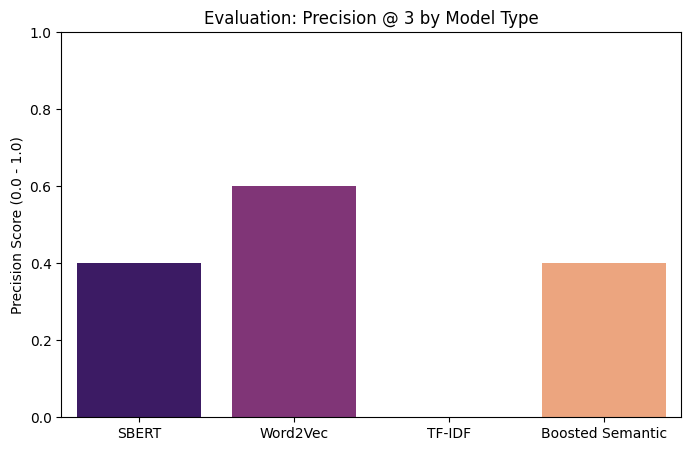

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8, 5))
models = ['SBERT', 'Word2Vec', 'TF-IDF','Boosted Semantic']
precision_values = [p3_sbert, p3_w2v,p3_tfidf,p3_bss]

sns.barplot(x=models, y=precision_values, palette='magma')
plt.title('Evaluation: Precision @ 3 by Model Type')
plt.ylabel('Precision Score (0.0 - 1.0)')
plt.ylim(0, 1)
plt.show()

              precision    recall  f1-score   support

Not Relevant       1.00      0.99      0.99     14381
    Relevant       0.26      0.41      0.32       100

    accuracy                           0.99     14481
   macro avg       0.63      0.70      0.66     14481
weighted avg       0.99      0.99      0.99     14481



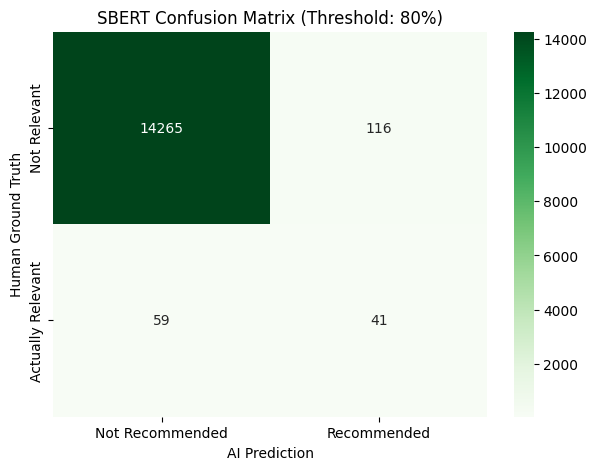

In [25]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Define your Ground Truth (Names you have manually verified as 'Top Tier')
# Add more names to this list based on your dataset inspection
# ground_truth_names = ['Samantha Santos', 'Mr. David Boyle', 'Carlos Dawson', 'Robert Thompson']
# ground_truth_names  = ['jack thompson','sophie williams','leandro sánchez','igor petrov','fatima al -hassan']
ground_truth_names = ["jack thompson","sophie williams","samuel o'connell","igor petrov","leandro silva"]

# 2. Create the Binary Columns
# y_true: 1 if human says they are good, 0 otherwise
merged_df['y_true'] = merged_df['name'].apply(lambda x: 1 if x in ground_truth_names else 0)

# y_pred: 1 if AI score is high (e.g., > 80), 0 otherwise
threshold = 80
merged_df['y_pred'] = merged_df['Final_Match_Score'].apply(lambda x: 1 if x >= threshold else 0)

# 3. Generate Confusion Matrix
cm = confusion_matrix(merged_df['y_true'], merged_df['y_pred'])

# 4. Plotting
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Not Recommended', 'Recommended'], 
            yticklabels=['Not Relevant', 'Actually Relevant'])

plt.title(f'SBERT Confusion Matrix (Threshold: {threshold}%)')
plt.xlabel('AI Prediction')
plt.ylabel('Human Ground Truth')
plt.savefig('confusion_matrix.png')

# 5. Print the Technical Report
print(classification_report(merged_df['y_true'], merged_df['y_pred'], target_names=['Not Relevant', 'Relevant']))

In [26]:
def generate_explanation_v4(row):
    # 1. Experience Note
    gap = row['experience_gap']
    if gap >= 0:
        exp_text = f"Meets or exceeds requirements (Has: {row['resume_experience_years']} yrs)."
    else:
        exp_text = f"Experience gap of {abs(gap)} years detected."

    # 2. Skill Logic (Separating Direct vs Semantic matches)
    matched = row['matched_skills_list']
    required = row['required_skills_list']
    missing = [s for s in required if s not in matched]
    
    # 3. Dynamic AI Note based on Score
    score = row['Final_Match_Score']
    if score >= 80:
        insight = "Strong candidate: Technical background is a direct match for job complexity."
    elif score >= 65:
        insight = "Potential match: Transferable skills identified despite keyword gaps."
    else:
        insight = "Low alignment: Candidate background deviates significantly from core requirements."

    return (
        f"**Summary:** {row['name']} ({score}%)\n"
        f"- **Exp:** {exp_text}\n"
        f"- **Skills:** Matched {len(matched)} key skills: {', '.join(matched)}.\n"
        f"- **Gaps:** Missing: {', '.join(missing) if missing else 'None'}.\n"
        f"- **AI Note:** {insight}"
    )

merged_df['Detailed_Explanation'] = merged_df.apply(generate_explanation_v4, axis=1)
merged_df.columns

Index(['application_name', 'str_resume', 'name', 'job_role', 'resume_skills',
       'education', 'certifications', 'resume_experience_years',
       'resume_skills_list', 'required_experience_years_num',
       'required_skills', 'keywords', 'required_skills_list', 'keywords_list',
       'resume_text_for_bert', 'job_text_for_bert', 'experience_gap',
       'expanded_resume_skills', 'matched_skills_list', 'skill_match_count',
       'resume_text', 'job_text', 'semantic_similarity_score',
       'boosted_semantic_score', 'Final_Match_Score', 'tfidf_similarity',
       'w2v_similarity', 'y_true', 'y_pred', 'Detailed_Explanation'],
      dtype='object')

In [27]:
'''
Rank candidates using multiple levels
# 1. Match Score (Primary)
# 2. Experience Years (Secondary)
# 3. Raw Semantic Score (Tertiary - the ultimate tie-breaker)
# 4. Skill Density (Quaternary)
'''
# option 4 as last resort
merged_df['skill_density'] = merged_df['skill_match_count'] / merged_df['expanded_resume_skills'].apply(len)

# Set the max column width to None (unlimited)
pd.set_option('display.max_colwidth', None)

# rank by score and resume experience
# ranked_results = merged_df[['Name', 'job_role', 'Final_Match_Score', 'Detailed_Explanation','resume_experience_years','semantic_similarity_score']].sort_values(
#     by=['Final_Match_Score','resume_experience_years','semantic_similarity_score'], ascending=[False,False,False]
# )

ranked_results = merged_df[['name','job_role' ,'semantic_similarity_score', 'Final_Match_Score', 'Detailed_Explanation','resume_experience_years']].sort_values(
    by=['Final_Match_Score','resume_experience_years','semantic_similarity_score'], ascending=[False,False,False]
)

# Preview the top candidate for each role
# ranked_results.groupby('job_role').head(1)
ranked_results.groupby('job_role').head()
# ranked_results.groupby('job_role').head(1)['Detailed_Explanation']
# ranked_results.groupby('job_role').head()['Detailed_Explanation']
# ranked_results.groupby('job_role').head(1)['Explanation']


# Preview the top candidate on final score
# max(merged_df['Final_Match_Score'])
# ranked_results.groupby('Final_Match_Score').head(1)
# ranked_results.groupby('Final_Match_Score').head(1)['Detailed_Explanation']
# ranked_results.head(1)
# ranked_results.head(1)['Detailed_Explanation']


# matching_skills_mask = merged_df['matched_skills_list'].apply(len) > 0

# # Filter the dataframe
# rows_with_matches = merged_df[matching_skills_mask]

# # Display a few key columns to verify
# print(f"Found {len(rows_with_matches)} candidates with direct skill matches.")
# display(rows_with_matches[['Name', 'job_role', 'matched_skills_list', 'skill_match_count']].head())


,name,job_role,semantic_similarity_score,Final_Match_Score,Detailed_Explanation,resume_experience_years
116,bashir jalloh,data engineer,73.01,95.34,"**Summary:** bashir jalloh (95.34%)\n- **Exp:** Meets or exceeds requirements (Has: 6.0 yrs).\n- **Skills:** Matched 6 key skills: mongodb, hadoop basics, aws cloud basics, python, sql, postgresql.\n- **Gaps:** Missing: None.\n- **AI Note:** Strong candidate: Technical background is a direct match for job complexity.",6.0
471,igor petrov,data engineer,76.44,93.39,"**Summary:** igor petrov (93.39%)\n- **Exp:** Meets or exceeds requirements (Has: 6.0 yrs).\n- **Skills:** Matched 7 key skills: aws redshift, java, spark, airflow, kafka, python, sql.\n- **Gaps:** Missing: azure data lake.\n- **AI Note:** Strong candidate: Technical background is a direct match for job complexity.",6.0
739,marcus thompson,data engineer,75.47,93.30,"**Summary:** marcus thompson (93.3%)\n- **Exp:** Meets or exceeds requirements (Has: 6.0 yrs).\n- **Skills:** Matched 8 key skills: snowflake, airflow, hadoop, kafka, python, bigquery, sql, scala.\n- **Gaps:** Missing: data governance.\n- **AI Note:** Strong candidate: Technical background is a direct match for job complexity.",6.0
465,igor petrov,data engineer,74.87,92.99,"**Summary:** igor petrov (92.99%)\n- **Exp:** Meets or exceeds requirements (Has: 6.0 yrs).\n- **Skills:** Matched 8 key skills: java, airflow, redshift, kafka, apache spark, sql optimization, python, scala.\n- **Gaps:** Missing: aws s3.\n- **AI Note:** Strong candidate: Technical background is a direct match for job complexity.",6.0
294,eva smits,product designer,66.92,92.16,"**Summary:** eva smits (92.16%)\n- **Exp:** Meets or exceeds requirements (Has: 4.0 yrs).\n- **Skills:** Matched 6 key skills: adobe xd, responsive design, wireframing, sketch, basic javascript, figma.\n- **Gaps:** Missing: None.\n- **AI Note:** Strong candidate: Technical background is a direct match for job complexity.",4.0
...,...,...,...,...,...,...
6313,morshed hasan,sales executive,25.01,40.28,"**Summary:** morshed hasan (40.28%)\n- **Exp:** Meets or exceeds requirements (Has: 8.0 yrs).\n- **Skills:** Matched 0 key skills: .\n- **Gaps:** Missing: product demos, closing deals, salesforce, negotiation, hubspot, social selling, lead generation, time management, sales forecasting, pipeline management.\n- **AI Note:** Low alignment: Candidate background deviates significantly from core requirements.",8.0
6316,morshed hasan,sales executive,25.01,40.28,"**Summary:** morshed hasan (40.28%)\n- **Exp:** Meets or exceeds requirements (Has: 8.0 yrs).\n- **Skills:** Matched 0 key skills: .\n- **Gaps:** Missing: product demos, closing deals, salesforce, negotiation, hubspot, social selling, lead generation, time management, sales forecasting, pipeline management.\n- **AI Note:** Low alignment: Candidate background deviates significantly from core requirements.",8.0
6319,morshed hasan,sales executive,25.01,40.28,"**Summary:** morshed hasan (40.28%)\n- **Exp:** Meets or exceeds requirements (Has: 8.0 yrs).\n- **Skills:** Matched 0 key skills: .\n- **Gaps:** Missing: product demos, closing deals, salesforce, negotiation, hubspot, social selling, lead generation, time management, sales forecasting, pipeline management.\n- **AI Note:** Low alignment: Candidate background deviates significantly from core requirements.",8.0
24,alexandra paul | site reliability engineer (sre) | alexandra .paul@email.com | (+34) 666 777 888,,34.03,39.49,"**Summary:** alexandra paul | site reliability engineer (sre) | alexandra .paul@email.com | (+34) 666 777 888 (39.49%)\n- **Exp:** Experience gap of 4.0 years detected.\n- **Skills:** Matched 2 key skills: r, gcp.\n- **Gaps:** Missing: c++, kubernetes, docker, shap, llms, azure, pytorch, computer vision, aws, keras, lime, java, spark, reinforcement learning, hugging face, cicd, deep learning, python, tensorflow, nlp, hadoop, scikit-learn.\n- **AI Note:** Low alignment: Candidate background deviates s

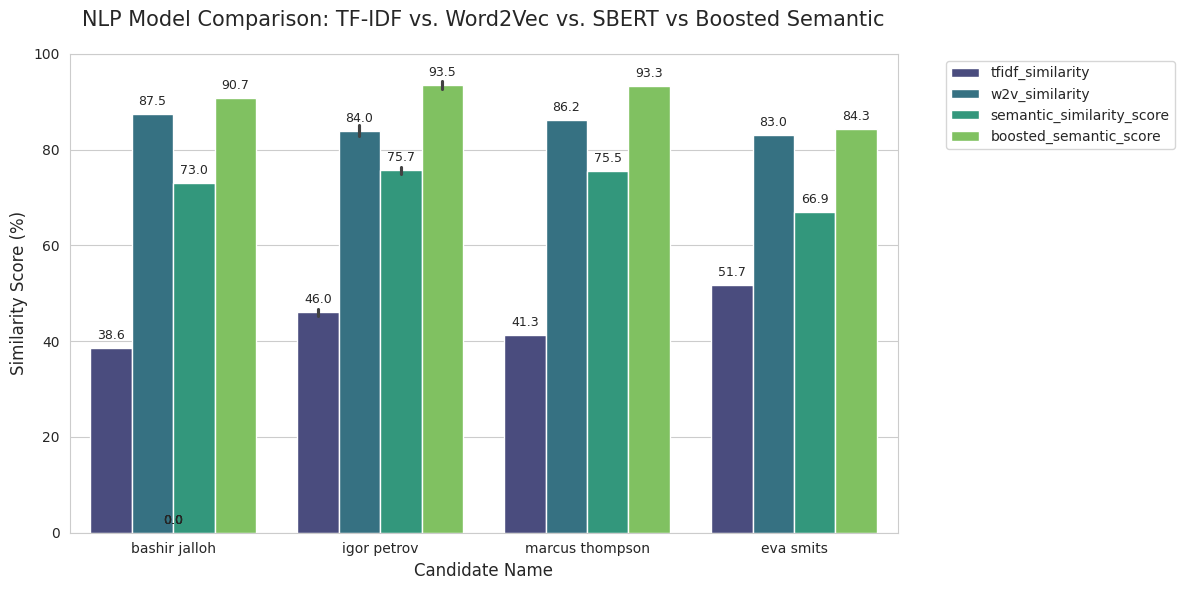

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Select the top 5 candidates to keep the chart clean
top_candidates = merged_df.nlargest(5, 'Final_Match_Score')

# 2. Melt the dataframe to make it 'Long-form' (perfect for Seaborn bar charts)
plot_data = top_candidates.melt(
    id_vars=['name'], 
    value_vars=['tfidf_similarity', 'w2v_similarity', 'semantic_similarity_score','boosted_semantic_score'],
    var_name='Model Type', 
    value_name='Similarity Score'
)

# 3. Create the plot
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

ax = sns.barplot(data=plot_data, x='name', y='Similarity Score', hue='Model Type', palette='viridis')

# Add labels and title
plt.title('NLP Model Comparison: TF-IDF vs. Word2Vec vs. SBERT vs Boosted Semantic', fontsize=15, pad=20)
plt.ylabel('Similarity Score (%)', fontsize=12)
plt.xlabel('Candidate Name', fontsize=12)
plt.ylim(0, 100) # Ensure scale is comparable
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Add value labels on top of bars
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.1f'), 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha = 'center', va = 'center', 
                   xytext = (0, 9), 
                   textcoords = 'offset points',
                   fontsize=9)

plt.tight_layout()
plt.show()